# Redox Interface Detection: Algortihm vs Human

## Objective
This notebook implements the fully refined logic and calculates the final statistics against the human baseline.

**Data Adjustments:**
1. **Calibration Shift:** All raw `Redox_mV` values are shifted by `+225 mV`.
2. **DEMO 6 Depth Shift:** All logs for `DEMO` with ID starting with `6` have their `Depth` shifted by `+2.0 meters`.

**Algorithm Logic:**
- Identifies the undoubtedly reduced stable stretch.
- Finds the closest drop event leading into it.
- Places the main interface where the calibrated potential finally drops below `50mV`.


In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)

# Load Project Data
df_redox = pd.read_csv('../Python_Redox_Geochemistry/Redox/Master_Redox.csv')

# APPLY CALIBRATION SHIFT
df_redox['Redox_mV'] = df_redox['Redox_mV'] + 225.0

# APPLY DEMO 6 DEPTH SHIFT (+2.0m)
demo6_mask = (df_redox['LOOPNr'] == 'DEMO') & (df_redox['ID'].astype(str).str.startswith('6'))
df_redox.loc[demo6_mask, 'Depth'] = df_redox.loc[demo6_mask, 'Depth'] + 2.0

# Parse DateTime to Date
if 'DateTime' in df_redox.columns:
    df_redox['Date'] = pd.to_datetime(df_redox['DateTime']).dt.date

# Load Refined Index
index_path = 'Refined_Human_Interface.csv'
df_index = pd.read_csv(index_path)
df_index['LOOPNr'] = df_index['Source_File'].astype(str).apply(lambda x: x.replace('\\', '/').split('/')[0])

def extract_date(filename):
    match = re.search(r'_(\d{8})_', str(filename))
    if match:
        date_str = match.group(1)
        return pd.to_datetime(date_str, format='%Y%m%d').date()
    return None

df_index['Date'] = df_index['Source_File'].apply(extract_date)

print(f"Loaded and adjusted Master Redox with {len(df_redox)} points.")
print(f"Loaded Index with {len(df_index)} entries.")

Loaded and adjusted Master Redox with 31309 points.
Loaded Index with 110 entries.


In [2]:
def detect_interfaces(df_subset):
    """
    Applies the 2026 Interface Detection Algorithm to a single borehole log.
    Returns: m_z (Auto_1 depth), m_d (Auto_1 drop), s_z (Auto_2 depth), s_d (Auto_2 drop), df_debug
    """
    # 1. Pre-processing
    df_clean = df_subset.dropna(subset=["Redox_mV"]).copy()
    df_grouped = df_clean.groupby("Depth")["Redox_mV"].mean().reset_index().sort_values("Depth")
    
    depth = df_grouped["Depth"].values
    redox = df_grouped["Redox_mV"].values
    
    if len(depth) < 10:
        return np.nan, np.nan, np.nan, np.nan, df_clean
    
    # Calculate average depth step
    dz_avg = np.mean(np.diff(depth))
    if dz_avg <= 0: return np.nan, np.nan, np.nan, np.nan, df_clean
        
    df = pd.DataFrame({'Depth': depth, 'Redox': redox})
    
    # 2. Resolution-Adaptive Smoothing (approx 0.5m)
    win_smooth = max(3, int(0.5 / dz_avg))
    df['Smooth'] = df['Redox'].rolling(window=win_smooth, center=True, min_periods=1).mean()
    
    # 3. Gradient Calculation (approx 1.5m drop)
    win_drop = max(3, int(1.5 / dz_avg))
    df['Drop'] = df['Smooth'].shift(win_drop) - df['Smooth']
    
    min_drop = 150.0  
    
    # Collect candidates
    valid_candidates = []
    for i in range(win_drop, len(df)):
        if df['Drop'].iloc[i] > min_drop:
            valid_candidates.append({'z': df['Depth'].iloc[i], 'drop': df['Drop'].iloc[i], 'idx': i})
                
    if not valid_candidates:
        return np.nan, np.nan, np.nan, np.nan, df
        
    df_cand = pd.DataFrame(valid_candidates).sort_values('z')
    
    # 4. Event Clustering
    clusters = []
    current_cluster = [df_cand.iloc[0]]
    for j in range(1, len(df_cand)):
        row = df_cand.iloc[j]
        if row['idx'] - current_cluster[-1]['idx'] <= 3:
            current_cluster.append(row)
        else:
            clusters.append(current_cluster)
            current_cluster = [row]
    clusters.append(current_cluster)
    
    # Peak Selection
    interfaces_pre = []
    for cluster in clusters:
        cdf = pd.DataFrame(cluster)
        best_idx = cdf['drop'].idxmax()
        interfaces_pre.append({'z': cdf.loc[best_idx, 'z'], 'drop': cdf.loc[best_idx, 'drop']})
        
    # 5. Proximity Filtering (1.4m rule)
    final_interfaces = []
    interfaces_pre = sorted(interfaces_pre, key=lambda x: x['z'])
    
    if interfaces_pre:
        current_inf = interfaces_pre[0]
        for inf in interfaces_pre[1:]:
            if inf['z'] - current_inf['z'] <= 1.4:
                if inf['drop'] > current_inf['drop']:
                    current_inf = inf
            else:
                final_interfaces.append(current_inf)
                current_inf = inf
        final_interfaces.append(current_inf)
        
    # 6. Stable Reduced Stretch Identification
    df['is_stable'] = (df['Smooth'] < 100) & (df['Drop'].abs() < 75)
    
    df['block_id'] = (~df['is_stable']).cumsum()
    stable_blocks = df[df['is_stable']].groupby('block_id')
    
    best_block = None
    max_len = 0
    for block_id, block in stable_blocks:
        length = block['Depth'].max() - block['Depth'].min()
        if length > max_len:
            max_len = length
            best_block = block
            
    main_drop_inf = None
    if best_block is not None and not best_block.empty:
        z_stable_start = best_block['Depth'].min()
        # Minimize distance to the start of the block
        valid_main = [inf for inf in final_interfaces if inf['z'] <= z_stable_start + 1.0]
        if valid_main:
            main_drop_inf = min(valid_main, key=lambda x: abs(x['z'] - z_stable_start))
        else:
            main_drop_inf = min(final_interfaces, key=lambda x: abs(x['z'] - z_stable_start))
    else:
        main_drop_inf = sorted(final_interfaces, key=lambda x: x['drop'], reverse=True)[0]

    # 7. Primary Interface Declaration (50mV threshold adjustment)
    df_below = df[df['Depth'] >= main_drop_inf['z']]
    df_below_50 = df_below[df_below['Redox'] < 50.0]
    
    if not df_below_50.empty:
        adjusted_main_z = df_below_50.iloc[0]['Depth']
    else:
        adjusted_main_z = main_drop_inf['z']
        
    m_z = adjusted_main_z
    m_d = main_drop_inf['drop']
    
    # 8. Secondary Interface Declaration (100mV Threshold)
    s_z = np.nan
    s_d = np.nan
    secondary_threshold_mv = 100.0
    if len(final_interfaces) > 1:
        remaining = [inf for inf in final_interfaces if inf['z'] != main_drop_inf['z']]
        remaining = sorted(remaining, key=lambda x: x['drop'], reverse=True)
        for inf in remaining:
            inf_z = inf['z']
            redox_at_z = df.loc[df['Depth'] == inf_z, 'Redox'].values
            if len(redox_at_z) > 0 and redox_at_z[0] <= secondary_threshold_mv:
                s_z = inf_z
                s_d = inf['drop']
                break
        
    return m_z, m_d, s_z, s_d, df


In [3]:
def plot_comparison(loop, bh_id, expected, electrode, date, best_auto_match=None):
    mask = (df_redox['LOOPNr'] == loop) & (df_redox['ID'] == str(bh_id))
    df_bh = df_redox[mask].copy()

    if electrode:
        df_bh = df_bh[df_bh['Electrode_Label'] == electrode]
    
    if date:
        df_bh = df_bh[df_bh['Date'] == date]

    if df_bh.empty: return

    m_z, m_d, s_z, s_d, debug = detect_interfaces(df_bh)
    if debug is None or debug.empty: return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    ax1.scatter(df_bh['Redox_mV'], df_bh['Depth'], s=1, color='gray', alpha=0.2)
    if 'Smooth' in debug.columns:
        ax1.plot(debug['Smooth'], debug['Depth'], 'b-', lw=2, label='Smooth Trend (Calibrated)')
        ax1.axvline(50, color='blue', ls=':', alpha=0.5, label='50mV Threshold')
    
    if not np.isnan(expected): 
        ax1.axhline(expected, color='g', ls='-', lw=2, label=f'Human: {expected}')
        
    if not np.isnan(m_z):
        ax1.axhline(m_z, color='red', ls='--', lw=2, label=f'Auto Main: {m_z:.2f}m')
    
    if not np.isnan(s_z):
        ax1.axhline(s_z, color='orange', ls='--', lw=1.5, label=f'Auto Secondary: {s_z:.2f}m')
        
    ax1.set_title(f'{loop} {bh_id} - {electrode} ({date})')
    ax1.invert_yaxis()
    
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if 'Drop' in debug.columns:
        ax2.plot(debug['Drop'], debug['Depth'], 'k-')
        ax2.axvline(150, color='r', ls='--', alpha=0.5, label='Min Drop Threshold')
        ax2.set_title('Redox Drop')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()


In [4]:
# Run over all labeled datasets to compute RMSE
results = []

for idx, row in df_index.iterrows():
    human_val_str = str(row['Human_Interface_2025_Separated']).strip().lower()
    if 'not stable' in human_val_str or 'no geochemistry' in human_val_str or 'no stable' in human_val_str:
        continue
        
    try:
        human_val = float(row['Human_Interface_2025_Separated'])
    except ValueError:
        continue 
        
    bh_loop = row['LOOPNr']
    bh_id = str(row['ID'])
    electrode = str(row['Electrode'])
    date = row['Date']
    
    mask = (df_redox['LOOPNr'] == bh_loop) & (df_redox['ID'] == bh_id)
    df_sub = df_redox[mask]
    
    if 'Electrode_Label' in df_sub.columns:
        if electrode in df_sub['Electrode_Label'].unique():
            df_sub = df_sub[df_sub['Electrode_Label'] == electrode]
            
    if date is not None and 'Date' in df_sub.columns:
        df_sub = df_sub[df_sub['Date'] == date]
            
    if df_sub.empty:
        continue
        
    m_z, m_d, s_z, s_d, df_calc = detect_interfaces(df_sub)
    
    results.append({
        'LOOPNr': bh_loop,
        'ID': bh_id,
        'Electrode': electrode,
        'Date': date,
        'Human_Interface': human_val,
        'Auto_Interface': m_z,
        'Auto_Secondary': s_z,
        'Error': (m_z - human_val) if not np.isnan(m_z) else np.nan
    })

df_results = pd.DataFrame(results)
df_results_clean = df_results.dropna(subset=['Auto_Interface']).copy()

rmse = np.sqrt((df_results_clean['Error']**2).mean())
mae = df_results_clean['Error'].abs().mean()

print(f"Processed {len(df_results)} valid electrode-date runs.")
print(f"Machine found interface in {len(df_results_clean)} logs.")
print(f"Root Mean Square Error: {rmse:.3f} m")
print(f"Mean Absolute Error: {mae:.3f} m")


Processed 93 valid electrode-date runs.
Machine found interface in 93 logs.
Root Mean Square Error: 1.039 m
Mean Absolute Error: 0.611 m


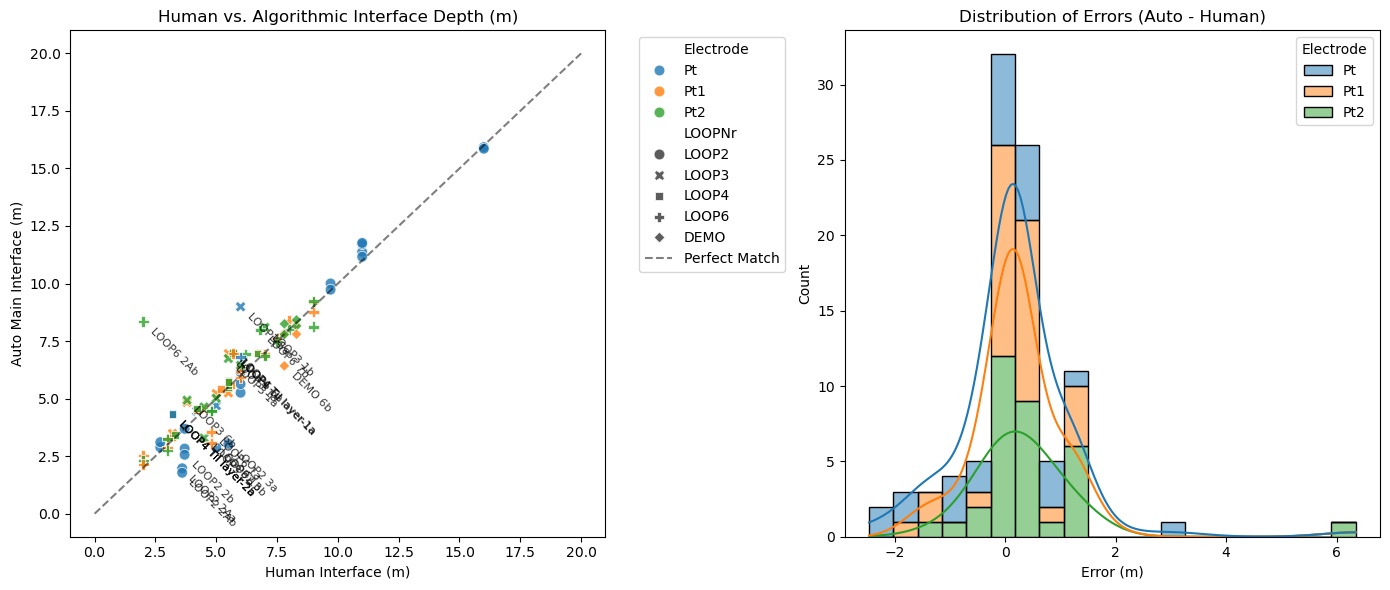

In [5]:
# Visualization 1: Scatterplot Human vs Auto
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_results_clean, x='Human_Interface', y='Auto_Interface', hue='Electrode', style='LOOPNr', s=60, alpha=0.8)
plt.plot([0, 20], [0, 20], 'k--', alpha=0.5, label='Perfect Match')

annotation_threshold = rmse
outliers = df_results_clean[df_results_clean['Error'].abs() > annotation_threshold]
for idx, row in outliers.iterrows():
    plt.text(row['Human_Interface'] + 0.2, row['Auto_Interface'] - 0.2, 
             f"{row['LOOPNr']} {row['ID']}", 
             horizontalalignment='left', 
             verticalalignment='top',
             fontsize=8, 
             alpha=0.8,
             rotation=-45)

plt.title('Human vs. Algorithmic Interface Depth (m)')
plt.xlabel('Human Interface (m)')
plt.ylabel('Auto Main Interface (m)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.histplot(data=df_results_clean, x='Error', hue='Electrode', multiple='stack', kde=True)
plt.title('Distribution of Errors (Auto - Human)')
plt.xlabel('Error (m)')

plt.tight_layout()
plt.show()

Visualizing top outliers for the Golden Roast logic:

Borehole: LOOP6 2Ab - Pt2 (2021-02-24) | Error: 6.35m


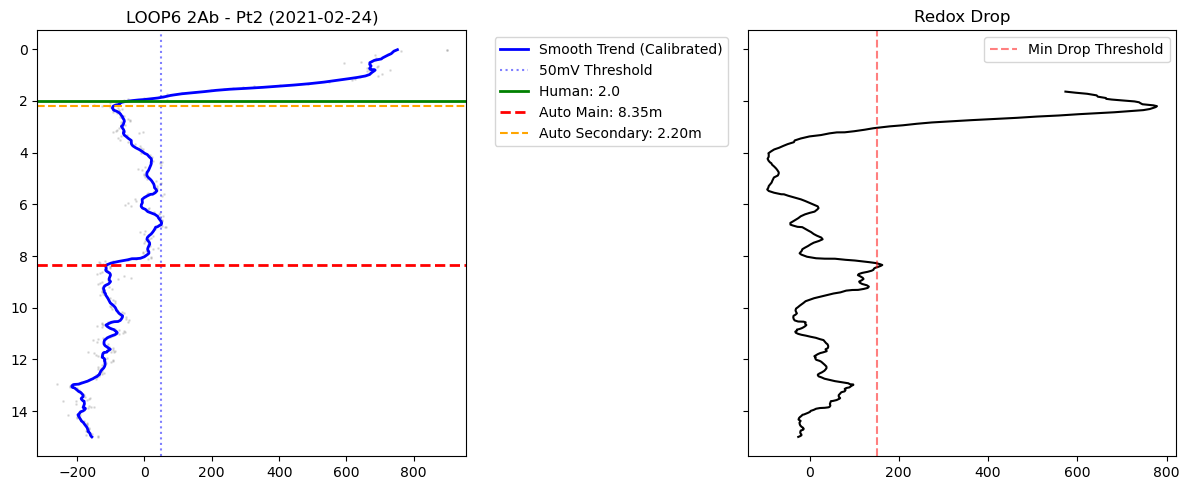


Borehole: LOOP3 5a - Pt (2020-11-13) | Error: 2.99m


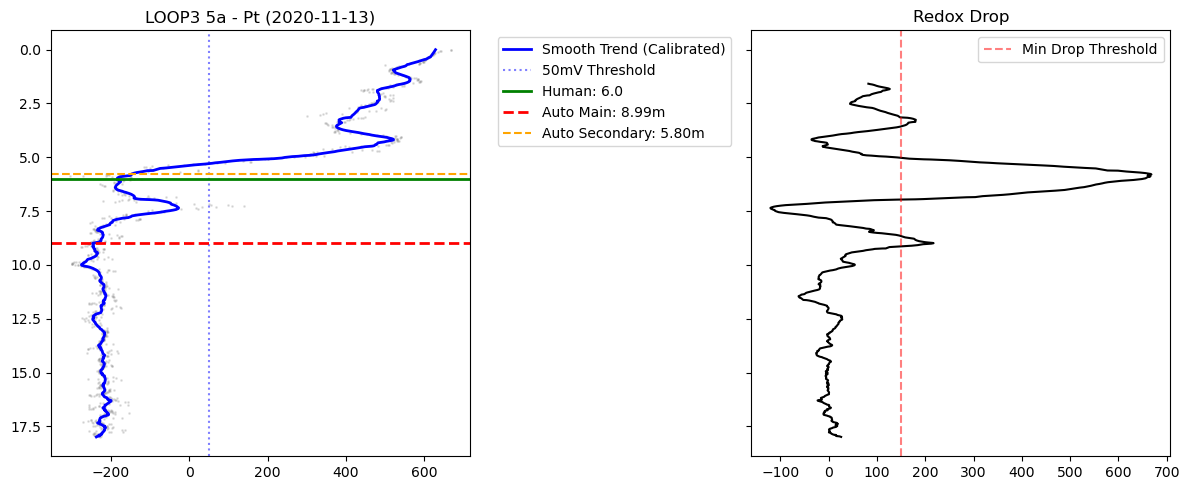


Borehole: LOOP2 3a - Pt (2020-04-01) | Error: -2.47m


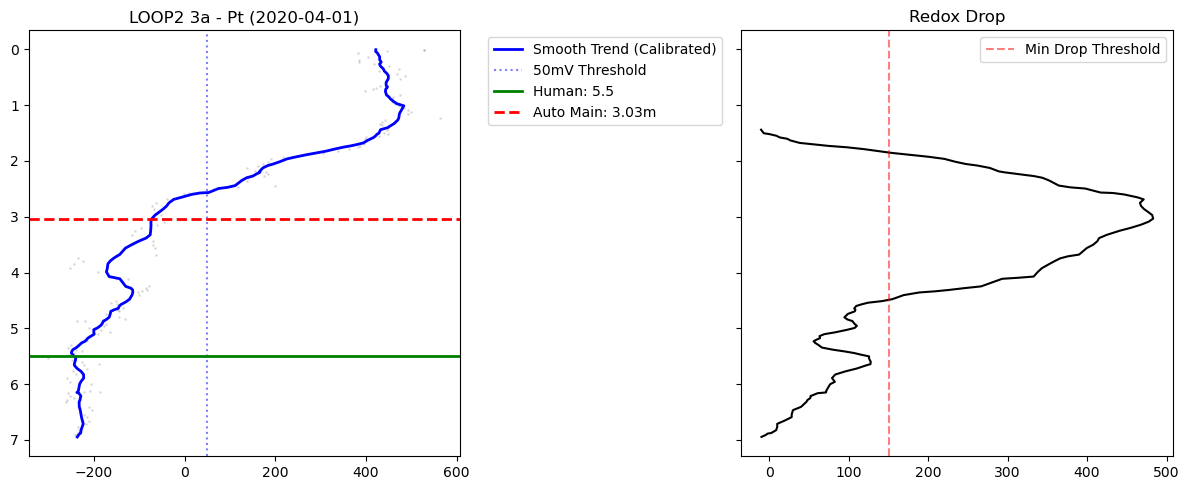


Borehole: LOOP2 3b - Pt (2020-04-01) | Error: -2.13m


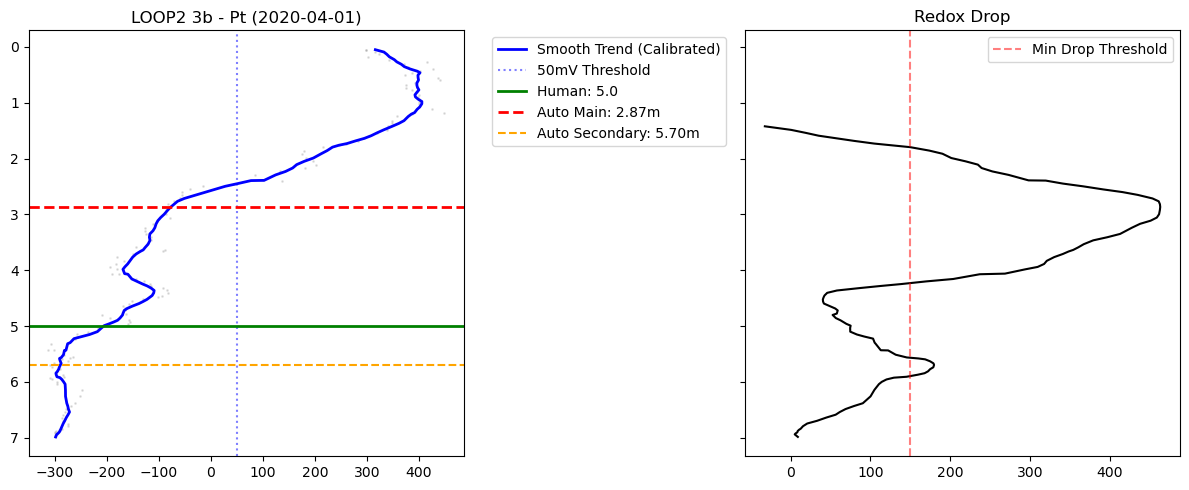


Borehole: LOOP2 2Ab - Pt (2020-04-01) | Error: -1.82m


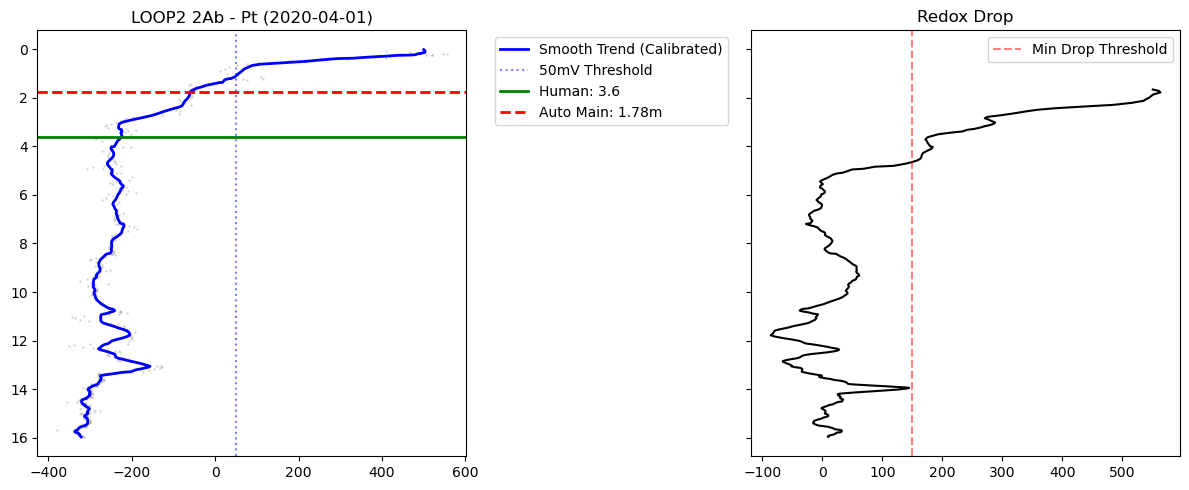

In [6]:
# Detailed Review of Outliers
df_results_clean["Abs_Error"] = df_results_clean["Error"].abs()
worst_matches = df_results_clean.sort_values("Abs_Error", ascending=False).head(5)

print("Visualizing top outliers for the Golden Roast logic:")
for idx, row in worst_matches.iterrows():
    print(f"\nBorehole: {row['LOOPNr']} {row['ID']} - {row['Electrode']} ({row['Date']}) | Error: {row['Error']:.2f}m")
    plot_comparison(
        row["LOOPNr"], 
        row["ID"], 
        row["Human_Interface"], 
        row["Electrode"], 
        row["Date"],
        best_auto_match=row["Auto_Interface"]
    )